# Data Cleaning & Preparation

## Objective
- ทำความสะอาดข้อมูล โดยแก้ไขปัญหาคุณภาพข้อมูลที่พบจากขั้นตอน Data Understanding
- สร้าง feature ที่จำเป็นเพื่อเตรียมสำหรับการทำ ML Model แบบ Classificattion
- เตรียมข้อมูลแบ่งเป็น Train / Test เพื่อสร้าง Model

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

plt.rcParams['font.family'] = 'Tahoma'

In [11]:
orders = pd.read_csv("../data/raw/orders_report_Mar_2026.csv", encoding='utf-8-sig')

##  1. Data Cleaning

### 1.1 Filter only orders with สถานะการสั่งซื้อ "สำเร็จ"
เนื่องจาก commission จะถูกจ่ายจริงเฉพาะ orders "สำเร็จ" เท่านั้น   
ส่วน orders ที่ "รอดำเนินการ" หรือ "ยกเลิก" ยังไม่ใช่รายได้จริง
ดังนั้นเราจึงต้อง Filter เพื่อลดความเสี่ยงของ model ที่จะเรียนรู้จากข้อมูลที่ไม่เกิดรายได้จริง

In [12]:
orders = orders[orders['สถานะการสั่งซื้อ'] == 'สำเร็จ'].copy()
orders = orders.reset_index(drop=True)

orders.shape

(1158, 47)

## 1.2 Drop unnecessary columns

In [13]:
cols_to_drop = [
    'รหัสการสั่งซื้อ', 'สถานะการสั่งซื้อ', 'เลขที่คำสั่งซื้อ', 'ชื่อร้านค้า', 
    'ID ร้านค้า', 'รหัสรายการสินค้า', 'เลขที่ โมเดล', 
    'ประเภทสินค้า', 'ประเภทข้อเสนอ', 'พาร์ทเนอร์ในแคมเปญ', 
    'จำนวนเงินคืน(฿)', 'อัตราคอมมิชชั่นช้อปปี้ของสินค้า', 
    'ค่าคอมมิชชั่นของช้อปปี้ต่อชิ้น(฿)', 'อัตราคอมมิชชั่นร้านค้าของสินค้า', 
    'ค่าคอมมิชชั่นของแบรนด์์ต่อชิ้น(฿)', 'คอมมิชชั่นสินค้าโดยรวม(฿)', 
    'คอมมิชชั่นคำสั่งซื้อจาก Shopee(฿)', 'คอมมิชชั่นคำสั่งซื้อจากผู้ขาย(฿)', 
    'คอมมิชชั่นคำสั่งซื้อโดยรวม(฿)', 'ชื่อ MCN ที่ผูกไว้', 'รหัสสัญญา MCN', 
    'อัตราค่าบริการ MCN', 'ค่าบริการ MCN(฿)', 
    'อัตราค่าคอมมิชชั่นของพาร์ทเนอร์ตามข้อตกลง', 'สถานะสินค้า Affiliate', 
    'หมายเหตุสินค้า', 'ประเภทการแจกจ่าย', 'สถานะของผู้ซื้อ', 
    'Sub_id3', 'Sub_id4', 'Sub_id5', 'ช่องทาง'
]

orders = orders.drop(columns=cols_to_drop)
print(f"Columns หลัง drop: {orders.shape[1]}")

Columns หลัง drop: 15


### 1.3 Fix Data Types — Convert Datetime Columns

In [14]:
datetime_cols = ['เวลาที่สั่งซื้อ', 'เวลาที่สั่งซื้อสำเร็จ', 'เวลาคลิก']
for col in datetime_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

print(orders[datetime_cols].dtypes)
print(orders[datetime_cols].isnull().sum())

เวลาที่สั่งซื้อ          datetime64[ns]
เวลาที่สั่งซื้อสำเร็จ    datetime64[ns]
เวลาคลิก                 datetime64[ns]
dtype: object
เวลาที่สั่งซื้อ          0
เวลาที่สั่งซื้อสำเร็จ    0
เวลาคลิก                 0
dtype: int64


### 1.4 Filter products
เลือกเฉพาะ product ที่เรา focus ในการทำ content promote เป็นการทำ business scope ให้ pattern ของ model ชัดเจนขึ้น

In [15]:
allowed_products = [
    'colgateOpticWhite',
    'dentistemax',
    'judydoll',
    'nude',
    'flowdays',
    'oppo'
]

orders = orders[orders['Sub_id1'].isin(allowed_products)].copy()
orders = orders.reset_index(drop=True)

### 1.5 Filter Facebook Group
ตามเป้าหมายที่เรา focus กลุ่ม Facebook ที่เราเช่าเพื่อ promote สินค้า   
เลยต้อง filter รายได้จากช่องทางอื่นๆออก

In [16]:
print(orders['Sub_id2'].value_counts(dropna=False))

orders = orders[orders['Sub_id2'].notna()].copy()
orders = orders.reset_index(drop=True)

print(f"Order after filter {len(orders)}")

Sub_id2
purple    595
red       126
white      85
blue       36
NaN        11
Name: count, dtype: int64
Order after filter 842


### 1.6 Handle Missing Value

In [17]:
orders['L3 หมวดหมู่สากล'] = orders['L3 หมวดหมู่สากล'].fillna('unknown')

## 2. Feature Engineering

### 2.1 Time Features
สร้าง click_hour และ click_day_of_week เพื่อดูพฤติกรรมของผู้คนว่าช่วงเวลาและวันไหนที่มีเเนวโน้มสั่งซื้อสินค้าสูง/ต่ำ

In [18]:
orders['click_hour'] = orders['เวลาคลิก'].dt.hour
orders['click_day_of_week'] = orders['เวลาคลิก'].dt.dayofweek

print(orders[['click_hour', 'click_day_of_week']].describe().loc[['min','max']])

     click_hour  click_day_of_week
min         0.0                0.0
max        23.0                6.0


### 2.2 Create Target Variable : commission_level
แปลงค่า commission เป็นระดับเพื่อให้ model ใช้ในการตัดสินใจได้
- **High (1)** = ค่าคอมมิชชั่นสุทธิ > median
- **Low  (0)** = ค่าคอมมิชชั่นสุทธิ ≤ median   

ใช้ **median เป็น threshold** เพราะ distribution เป็น right-skewed เพื่อสะท้อนค่ากลางของข้อมูลที่เเท้จริงเพราะ mean มันถูก outlier ดึงขึ้น

In [19]:
median_commission = orders['ค่าคอมมิชชั่นสุทธิ(฿)'].median()

orders['commission_level'] = (orders['ค่าคอมมิชชั่นสุทธิ(฿)'] > median_commission).astype(int)

print(orders['commission_level'].value_counts())
print(orders['commission_level'].value_counts(normalize=True))

commission_level
0    423
1    419
Name: count, dtype: int64
commission_level
0    0.502375
1    0.497625
Name: proportion, dtype: float64


**Insights**  
ผลออกมาว่า   
- กลุ่ม Low (0) มี 423 รายการ (50.2%)   
- กลุ่ม High (1) มี 419 รายการ (49.8%)

class distribution มีความ balanced กันมาก ซึ่งเป็นเรื่องที่ดีมากเพราะ ทำให้ model ไม่ bias ไปทาง class ใด class หนึ่ง

### 2.3 Business Optimization: ROI per Facebook Group
ค่าเช่ากลุ่ม Facebook
- กลุ่ม white 200 บาท/เดือน
- กลุ่ม purple + red + blue = จ่ายเป็น package ราคา 1,000 บาท/100 วัน (จ่ายเเล้วโพสต์ได้ 3 กลุ่ม)
  
ต้องการวิเคราะห์ความคุ้มค่าของแต่ละกลุ่ม Facebook โดยเปรียบเทียบ รายได้ (ค่า commission) กับ ต้นทุนค่าเช่ากลุ่ม

In [20]:
# Cost
white_cost = 200
package_cost_march = 1000 * (31 / 100)
cost_per_package_group = package_cost_march / 3

# Revenue
commission_by_group = orders.groupby('Sub_id2')['ค่าคอมมิชชั่นสุทธิ(฿)'].sum().reset_index()

# Cost mapping
cost_map = {
    'white': white_cost,
    'purple': cost_per_package_group,
    'red': cost_per_package_group,
    'blue': cost_per_package_group
}

# ROI table
roi = commission_by_group.copy()
roi['cost'] = roi['Sub_id2'].map(cost_map)
roi['net_profit'] = roi['ค่าคอมมิชชั่นสุทธิ(฿)'] - roi['cost']
roi['roi_%'] = (roi['net_profit'] / roi['cost'] * 100).round(1)

# Result
print(roi.sort_values('roi_%', ascending=False))

  Sub_id2  ค่าคอมมิชชั่นสุทธิ(฿)        cost   net_profit   roi_%
1  purple             3345.55884  103.333333  3242.225507  3137.6
2     red             1008.19750  103.333333   904.864167   875.7
3   white              582.46712  200.000000   382.467120   191.2
0    blue              288.31000  103.333333   184.976667   179.0


**Insights**   
พบว่าทุกกลุ่มได้กำไรหมดเเต่ความคุ้มค่าต่างกัน
- กลุ่ม Purple (ของดีต้องแชร์ Shopee / Lazada)
  มี ROI สูงที่สุดอย่างชัดเจน (3137.6%) เป็นกลุ่มที่สร้างรายได้สูงมากเมื่อเทียบกับต้นทุน
- กลุ่ม Red (ช้อปขั้นเทพ)
    เป็นอันดับ 2 (875.7%) ยังเป็นกลุ่มที่มีประสิทธิภาพสูงในการสร้างรายได้
- กลุ่ม White (แต่งห้อง แต่งบ้าน แต่งเห๊อะ ขายทุกสิ่ง รีวิวทุกอย่าง)
    แม้มีต้นทุนสูงกว่า แต่ยังคงให้ ROI ที่ดี (191.2%) แสดงว่ากลุ่มนี้มี potential แต่ efficiency ต่ำกว่า purple และ red
- กลุ่ม Blue (รีวิวครอบจักรวาล)
  ให้ ROI ต่ำที่สุดในกลุ่ม package (179.0%) เป็นกลุ่มที่สร้างรายได้ได้น้อยเมื่อเทียบกับต้นทุน

ดังนั้นที่เราเช่าเป็น package (3 กลุ่ม purple, red, blue) ก็ถือว่าคุ้มมากเพราะมีกลุ่ม purple เเละทุกกลุ่มก็ได้กำไร

### 2.4 Time-based Behavioral Insight
วิเคราะห์ความสัมพันธ์ระหว่าง click_hour เเละ commission_level เพื่อหาช่วงเวลาที่มีประสิทธิภาพสูงสุดในการโพสต์ promote สินค้า

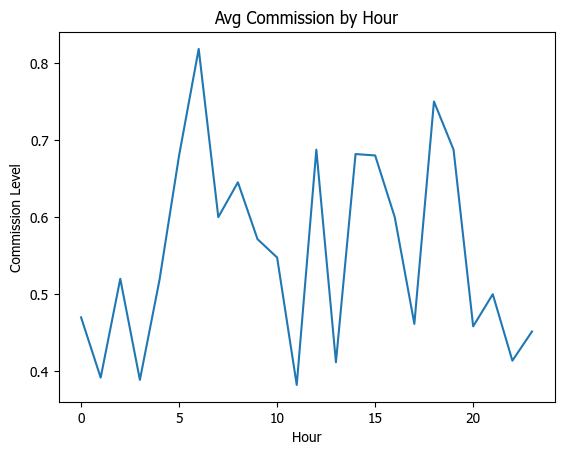

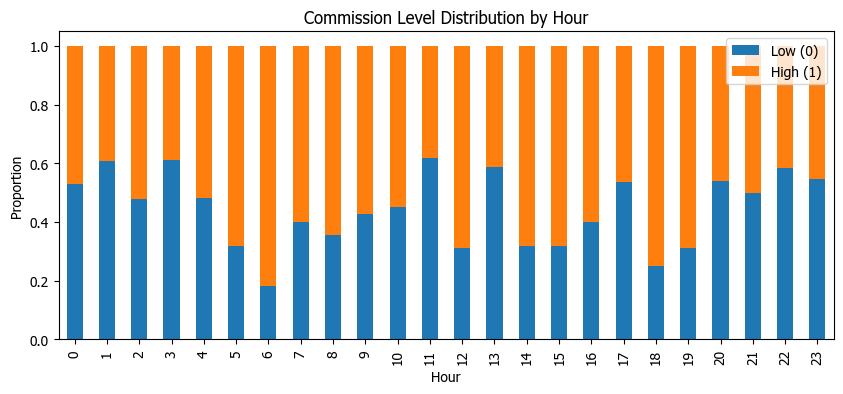

In [24]:
# Mean trend
orders.groupby('click_hour')['commission_level'].mean().plot()

plt.title('Avg Commission by Hour')
plt.xlabel('Hour')
plt.ylabel('Commission Level')
plt.show()

# Distribution
hour_dist = orders.groupby('click_hour')['commission_level'].value_counts(normalize=True).unstack()

hour_dist.plot(kind='bar', stacked=True, figsize=(10,4))

plt.title('Commission Level Distribution by Hour')
plt.xlabel('Hour')
plt.ylabel('Proportion')
plt.legend(['Low (0)', 'High (1)'])
plt.show()

**Insights**   
เวลาโพสต์มีผลต่อ performance ของ commission อย่างชัดเจน   
ช่วงเวลาที่ควรเน้นลงโพสต์ promote สินค้าคือ 6 โมงเช้า และ 6 โมงเย็น   
ช่วงเวลาที่ควรหลีกเลี่ยงการลงโพสต์คือ 11 โมง 

### 2.4 Prepare Features for ML Model
เตรียมข้อมูลสำหรับใช้ใน Machine Learning model   
โดยมีเป้าหมายให้ model predict ว่า order นี้จะ "High commission (1)" หรือ "Low commission (0)"   
ซึ่ง feature ที่เลือกคือ
- Sub_id1 = สินค้าที่ promote ใน post นั้น
- Sub_id2 = กลุ่ม Facebook ที่ใช้ในการโปรโมท
- click_hour = ชั่วโมงที่ผู้คนคลิก
- click_day_of_week = วันในสัปดาห์ที่ผู้คนคลิก

In [25]:
feature_cols = [
    'Sub_id1', 
    'Sub_id2',
    'click_hour',
    'click_day_of_week'
]

target_col = 'commission_level'

df_model = orders[feature_cols + [target_col]].copy()

print("Shape:", df_model.shape)
print(df_model.isnull().sum())
print(df_model.head())

Shape: (842, 5)
Sub_id1              0
Sub_id2              0
click_hour           0
click_day_of_week    0
commission_level     0
dtype: int64
    Sub_id1 Sub_id2  click_hour  click_day_of_week  commission_level
0      oppo  purple          10                  5                 1
1      oppo  purple          23                  6                 1
2      oppo  purple          23                  6                 0
3      oppo  purple          23                  6                 0
4  judydoll   white           2                  5                 1


## 3. Train / Test Split
ใช้สัดส่วน Train 80% และ Test 20%

In [26]:
X = df_model.drop(columns=['commission_level'])
y = df_model['commission_level']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

print("Train distribution:")
print(y_train.value_counts())

print("Test distribution:")
print(y_test.value_counts())

Train: (673, 4)
Test : (169, 4)
Train distribution:
commission_level
0    338
1    335
Name: count, dtype: int64
Test distribution:
commission_level
0    85
1    84
Name: count, dtype: int64


## 4. One-Hot Encoding
แปลงข้อมูลประเภท categorical ได้แก่ Sub_id1 และ Sub_id2 ให้อยู่ในรูปแบบที่ Machine Learning model สามารถนำไปใช้งานได้   
โดยที่ใช้ One-Hot Encoding เพื่อป้องกันการตีความผิดลำดับที่ไม่มีอยู่จริง

In [27]:
categorical_cols = [
    'Sub_id1', 
    'Sub_id2'
]
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoder.fit(X_train[categorical_cols])

X_train_encoded = encoder.transform(X_train[categorical_cols])
X_test_encoded  = encoder.transform(X_test[categorical_cols])

# Convert to DataFrame
encoded_cols = encoder.get_feature_names_out(categorical_cols)

X_train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=encoded_cols,
    index=X_train.index
)

X_test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=encoded_cols,
    index=X_test.index
)

# Merge
X_train = X_train.drop(columns=categorical_cols)
X_train = pd.concat([X_train, X_train_encoded_df], axis=1)

X_test = X_test.drop(columns=categorical_cols)
X_test = pd.concat([X_test, X_test_encoded_df], axis=1)

print("Final Train shape:", X_train.shape)
print("Final Test shape :", X_test.shape)

print(X_train.head())

Final Train shape: (673, 11)
Final Test shape : (169, 11)
     click_hour  click_day_of_week  Sub_id1_colgateOpticWhite  \
502           0                  6                        1.0   
612          21                  5                        0.0   
467           1                  1                        0.0   
568           0                  0                        0.0   
739           0                  3                        0.0   

     Sub_id1_flowdays  Sub_id1_judydoll  Sub_id1_nude  Sub_id1_oppo  \
502               0.0               0.0           0.0           0.0   
612               0.0               0.0           1.0           0.0   
467               0.0               1.0           0.0           0.0   
568               0.0               1.0           0.0           0.0   
739               0.0               1.0           0.0           0.0   

     Sub_id2_blue  Sub_id2_purple  Sub_id2_red  Sub_id2_white  
502           0.0             1.0          0.0            0.

## 5. Save Clean Data

In [20]:
df_model.to_csv("../data/processed/orders_cleaned.csv", index=False, encoding='utf-8-sig')
X_train.to_csv("../data/processed/X_train.csv", index=False)
X_test.to_csv("../data/processed/X_test.csv", index=False)
y_train.to_csv("../data/processed/y_train.csv", index=False)
y_test.to_csv("../data/processed/y_test.csv", index=False)

## 6. Save Encoder

In [28]:
import joblib

joblib.dump(encoder, "../models/encoder.pkl")

['../models/encoder.pkl']